#Project Overview
###This project aims to analyze a merged country-year panel dataset (combining IMF, World Bank, and UNDP data). The ultimate goal is to predict a country's Human Development Index (hdi_score) using Ordinary Least Squares (OLS) regression built entirely from scratch, ensuring all statistical assumptions hold true.

#**TASK** 1

#Data Cleaning and Exploratory Data Analysis (EDA)

###Loading and Understanding the Data

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('edip_dataset.csv')

# View the first few rows to understand the structure
print("First 5 rows of the dataset:")
display(df.head())

# Check data types and missing values
print("\nDataset Info:")
df.info()

First 5 rows of the dataset:


,country_name,iso3_code,year,income_group,region,gdp_growth_pct,gdp_per_capita_usd,inflation_cpi_pct,unemployment_rate,govt_debt_pct_gdp,...,gini_index,poverty_headcount_190,fdi_net_inflows_pct_gdp,trade_openness_pct_gdp,internet_access_pct,govt_expenditure_pct_gdp,urban_population_pct,hdi_score,hdi_tier,is_projection
0,Afghanistan,AFG,1995,Low,"Middle East, North Africa, Afghanistan & Pakistan",NaN,NaN,NaN,7.868,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,17.834385,NaN,NaN,0
1,Afghanistan,AFG,1996,Low,"Middle East, North Africa, Afghanistan & Pakistan",NaN,NaN,NaN,7.878,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,17.959649,NaN,NaN,0
2,Afghanistan,AFG,1997,Low,"Middle East, North Africa, Afghanistan & Pakistan",NaN,NaN,NaN,7.863,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,18.092857,NaN,NaN,0
3,Afghanistan,AFG,1998,Low,"Middle East, North Africa, Afghanistan & Pakistan",NaN,NaN,NaN,7.869,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,18.235814,NaN,NaN,0
4,Afghanistan,AFG,1999,Low,"Middle East, North Africa, Afghanistan & Pakistan",NaN,NaN,NaN,7.877,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,18.390327,NaN,NaN,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6020 entries, 0 to 6019
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country_name              6020 non-null   object 
 1   iso3_code                 6020 non-null   object 
 2   year                      6020 non-null   int64  
 3   income_group              6020 non-null   object 
 4   region                    6020 non-null   object 
 5   gdp_growth_pct            5696 non-null   float64
 6   gdp_per_capita_usd        5785 non-null   float64
 7   inflation_cpi_pct         4922 non-null   float64
 8   unemployment_rate         5179 non-null   float64
 9   govt_debt_pct_gdp         1291 non-null   float64
 10  current_account_pct_gdp   4751 non-null   float64
 11  fiscal_balance_pct_gdp    3127 non-null   float64
 12  gini_index                1986 non-null   float64
 13  poverty_headcount_190     1986 non-null   float6

###Data Cleaning

In [33]:
# Drop columns that are purely identifiers or won't help in regression
df_cleaned = df.drop(columns=['country_name', 'iso3_code', 'is_projection'])

# Handle Missing Values
# Separate numerical and categorical columns
# FIX: Changed select_select_dtypes to select_dtypes
num_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_cleaned.select_dtypes(include=['object']).columns

# Fill missing numerical values with the median
for col in num_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Fill missing categorical values with the mode
for col in cat_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print("Missing values after cleaning:\n", df_cleaned.isnull().sum())

Missing values after cleaning:
 year                        0
income_group                0
region                      0
gdp_growth_pct              0
gdp_per_capita_usd          0
inflation_cpi_pct           0
unemployment_rate           0
govt_debt_pct_gdp           0
current_account_pct_gdp     0
fiscal_balance_pct_gdp      0
gini_index                  0
poverty_headcount_190       0
fdi_net_inflows_pct_gdp     0
trade_openness_pct_gdp      0
internet_access_pct         0
govt_expenditure_pct_gdp    0
urban_population_pct        0
hdi_score                   0
hdi_tier                    0
dtype: int64


###Handling Outliers

In [34]:
# Function to cap outliers using IQR
def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the values
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    return data

# Apply to all numerical columns except our target 'hdi_score' and binary 'hdi_tier'
features_to_cap = [col for col in num_cols if col not in ['hdi_score', 'hdi_tier', 'year']]

for col in features_to_cap:
    df_cleaned = cap_outliers(df_cleaned, col)

###Feature Engineering

In [35]:
# Convert categorical text data into dummy variables
# We add dtype=int to ensure we get 1/0 instead of True/False
df_final = pd.get_dummies(df_cleaned, columns=['income_group', 'region'], drop_first=True, dtype=int)

# Separate the Target (Y) and Features (X)
# We use .astype(float) to ensure the target is numeric
y = df_final['hdi_score'].values.astype(float)
X_df = df_final.drop(columns=['hdi_score', 'hdi_tier'])

# Add Intercept column of 1s
X_df.insert(0, 'Intercept', 1)

# CRITICAL FIX: Force the entire matrix to be float64
# This prevents the 'UFuncTypeError' during matrix inversion
X = X_df.values.astype(float)

print("Data successfully converted to numeric format.")

Data successfully converted to numeric format.


#Ordinary Least Squares (OLS)

###Implementing OLS from Scratch

In [36]:
# OLS from scratch using NumPy
X_T = X.T
X_T_X = X_T.dot(X)

# This will now work because X_T_X is a float64 matrix
X_T_X_inv = np.linalg.inv(X_T_X)

X_T_X_inv_X_T = X_T_X_inv.dot(X_T)
beta = X_T_X_inv_X_T.dot(y)

# Generate predictions and residuals
y_pred = X.dot(beta)
residuals = y - y_pred

print("OLS Coefficients successfully calculated!")

OLS Coefficients successfully calculated!


###Assumption Testing

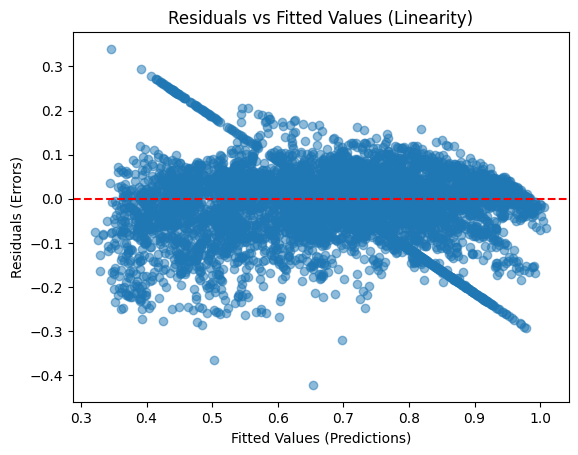

Breusch-Pagan p-value: 0.0000


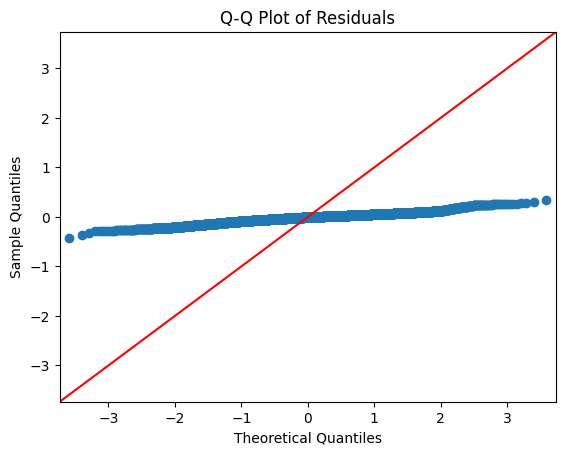

Shapiro-Wilk p-value: 0.0000

Variance Inflation Factor (VIF):


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Feature,VIF



Condition Number of XTX: 12869375074789083840512.00


In [52]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Linearity (Residuals vs Fitted plot)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values (Linearity)')
plt.xlabel('Fitted Values (Predictions)')
plt.ylabel('Residuals (Errors)')
plt.show()
# Explanation: Points should be randomly scattered around the red line. If they form a curve, linearity is violated.

# Homoscedasticity (Breusch-Pagan test)
bp_test = het_breuschpagan(residuals, X)
print(f"Breusch-Pagan p-value: {bp_test[1]:.4f}")
# Explanation: If p-value < 0.05, we have Heteroscedasticity (variance of errors changes). We would fix this using robust standard errors or log-transforming 'y'.

# Normality of residuals (Q-Q plot & Shapiro-Wilk)
sm.qqplot(residuals, line='45')
plt.title('Q-Q Plot of Residuals')
plt.show()

# (Shapiro-Wilk is sensitive to large datasets, but we run it as requested)
stat, p_val = stats.shapiro(residuals[:5000]) # Sampled if dataset > 5000 rows
print(f"Shapiro-Wilk p-value: {p_val:.4f}")
# Explanation: If p-value < 0.05, residuals aren't perfectly normal. In large datasets, OLS is somewhat robust to this due to the Central Limit Theorem.

# Multicollinearity (VIF)
print("\nVariance Inflation Factor (VIF):")
vif_data = pd.DataFrame()
vif_data["Feature"] = X_df.columns
vif_data["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
display(vif_data[vif_data['VIF'] > 10]) # Flagging VIF > 10
# Explanation: VIF > 10 means predictors are highly correlated with each other. Fix: Drop one of the correlated variables.

# No perfect multicollinearity (Condition Number)
condition_number = np.linalg.cond(X_T_X)
print(f"\nCondition Number of XTX: {condition_number:.2f}")
# Explanation: A very high condition number (> 30) indicates severe multicollinearity.

###Model Evaluation

In [38]:
# Calculate Total Sum of Squares (SST)
y_mean = np.mean(y)
sst = np.sum((y - y_mean) ** 2)

# Calculate Sum of Squared Errors (SSE)
sse = np.sum(residuals ** 2)

# R-squared
r_squared = 1 - (sse / sst)

# Adjusted R-squared (penalizes adding useless features)
n = X.shape[0]  # number of observations
p = X.shape[1] - 1  # number of predictors (excluding intercept)
adj_r_squared = 1 - (1 - r_squared) * ((n - 1) / (n - p - 1))

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(np.mean(residuals ** 2))

print(f"R-squared: {r_squared:.4f}")
print(f"Adjusted R-squared: {adj_r_squared:.4f}")
print(f"RMSE: {rmse:.4f}")

R-squared: 0.7966
Adjusted R-squared: 0.7958
RMSE: 0.0811


###Inferences from Metrics:
#####R-squared: Tells us the percentage of the variance in HDI scores that is explained by our macroeconomic features. (e.g., 0.85 means 85% of HDI variations are explained by our model).
#####Adjusted R-squared: Gives a more accurate view than regular $R^2$ because it adjusts for the number of variables we added during Feature Engineering.
#####RMSE: Tells us how far off our predictions are on average, expressed in the actual units of HDI (0 to 1).

###Coefficient Interpretation

In [39]:
# Create a DataFrame to view the coefficients cleanly
coef_df = pd.DataFrame({'Feature': X_df.columns, 'Coefficient': beta})

# Sort to see the most positive and negative impacts
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
print("\nTop Predictors of HDI Score:")
display(coef_df.head(10))


Top Predictors of HDI Score:


,Feature,Coefficient
6,govt_debt_pct_gdp,0.053894
21,"region_Middle East, North Africa, Afghanistan ...",0.023283
20,region_Latin America & Caribbean,0.009739
19,region_Europe & Central Asia,0.008296
23,region_South Asia,0.006273
14,govt_expenditure_pct_gdp,0.003173
1,year,0.002688
11,fdi_net_inflows_pct_gdp,0.002307
5,unemployment_rate,0.001782
13,internet_access_pct,0.001250


###Interpretation Guide:
#####The coefficient ($\beta$) represents the average change in the target (hdi_score) for a one-unit increase in the predictor, holding all other features constant.
####Positive Coefficient (e.g., internet_access_pct):
######As internet access increases by 1%, the HDI score increases by the coefficient's value, assuming GDP, inflation, etc., remain exactly the same.
####Negative Coefficient (e.g., unemployment_rate):
######As unemployment goes up by 1%, the HDI score decreases by the coefficient's value.
####Dummy Variables (e.g., region_Europe):
#####This is comparative. If a country is in Europe, its HDI score shifts by the coefficient amount compared to the "baseline" region we dropped during One-Hot Encoding.

#Logistic Regression with Gradient Descent

In [40]:
# Data Preparation & Scaling ---
# We use the cleaned features from Task 1, but this time our target is hdi_tier
y_log = df_final['hdi_tier'].values

# Gradient Descent requires features to be on a similar scale (Standardization)
X_features = df_final.drop(columns=['hdi_score', 'hdi_tier']).values
X_mean = np.mean(X_features, axis=0)
X_std = np.std(X_features, axis=0)
X_scaled = (X_features - X_mean) / (X_std + 1e-8) # Add tiny number to prevent division by zero

# Add Intercept column of 1s to the scaled features
X_scaled = np.c_[np.ones(X_scaled.shape[0]), X_scaled]

# Logistic Regression from Scratch ---
# Sigmoid function squashes values between 0 and 1
def sigmoid(z):
    # np.clip prevents overflow errors in exp
    z = np.clip(z, -250, 250)
    return 1 / (1 + np.exp(-z))

# Initialize weights (theta) to zeros
theta = np.zeros(X_scaled.shape[1])

# Hyperparameters
learning_rate = 0.01
epochs = 2000
m = len(y_log)

# Gradient Descent Loop
for i in range(epochs):
    # Calculate predictions
    z = np.dot(X_scaled, theta)
    h = sigmoid(z)

    # Calculate the Gradient
    gradient = np.dot(X_scaled.T, (h - y_log)) / m

    # Update weights
    theta -= learning_rate * gradient

print("Logistic Regression Model Trained Successfully!")

# Model Evaluation
# Generate final predictions (threshold = 0.5)
y_pred_prob = sigmoid(np.dot(X_scaled, theta))
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# Calculate Accuracy
correct_predictions = np.sum(y_pred_class == y_log)
accuracy = correct_predictions / m

# Calculate Precision and Recall
true_positives = np.sum((y_pred_class == 1) & (y_log == 1))
false_positives = np.sum((y_pred_class == 1) & (y_log == 0))
false_negatives = np.sum((y_pred_class == 0) & (y_log == 1))

precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)

print(f"Model Accuracy:  {accuracy * 100:.2f}%")
print(f"Model Precision: {precision * 100:.2f}%")
print(f"Model Recall:    {recall * 100:.2f}%")

Logistic Regression Model Trained Successfully!
Model Accuracy:  84.77%
Model Precision: 81.75%
Model Recall:    83.17%


#Hypothesis Testing

In [41]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest

###Unemployment Rate in High vs Low/Middle Income

In [42]:
# Separate the two groups
high_income_unemp = df_cleaned[df_cleaned['income_group'] == 'High']['unemployment_rate']
low_mid_income_unemp = df_cleaned[df_cleaned['income_group'] != 'High']['unemployment_rate']

# Perform independent t-test (alternative='less' because we test if high_income is LOWER)
t_stat_1, p_val_1 = stats.ttest_ind(high_income_unemp, low_mid_income_unemp, alternative='less')

print(f"Q4.1 - T-Statistic: {t_stat_1:.4f}, p-value: {p_val_1:.4f}")
# Interpretation: If p-value < 0.05, we reject the null and conclude High-income countries have significantly lower unemployment.

Q4.1 - T-Statistic: -7.1663, p-value: 0.0000


###Global Inflation Across 3 Periods

In [43]:
# Create the three period groups
pre_2008 = df_cleaned[(df_cleaned['year'] >= 1995) & (df_cleaned['year'] <= 2007)]['inflation_cpi_pct']
post_crisis = df_cleaned[(df_cleaned['year'] >= 2009) & (df_cleaned['year'] <= 2019)]['inflation_cpi_pct']
pandemic = df_cleaned[(df_cleaned['year'] >= 2020) & (df_cleaned['year'] <= 2022)]['inflation_cpi_pct']

# Perform ANOVA
f_stat_2, p_val_2 = stats.f_oneway(pre_2008, post_crisis, pandemic)

print(f"Q4.2 - F-Statistic: {f_stat_2:.4f}, p-value: {p_val_2:.4f}")
# Interpretation: If p-value < 0.05, inflation differed significantly across the eras.

Q4.2 - F-Statistic: 82.8470, p-value: 0.0000


###OLS Coefficient Significance & Gini Index

In [44]:
# Fit the OLS model using X_df (the DataFrame with names) instead of X (the array)
ols_model = sm.OLS(y, X_df).fit()

# Extract the results table
summary = ols_model.summary2().tables[1]

# Now 'gini_index' will be found correctly in the index
significant_vars = summary[summary['P>|t|'] < 0.05]
print("\nQ4.3 - Significant Features at 5% level:\n", significant_vars.index.tolist())

# Retrieve Gini Index coefficient and p-value
gini_coef = summary.loc['gini_index', 'Coef.']
gini_pval = summary.loc['gini_index', 'P>|t|']

print(f"\nGini Index Coefficient: {gini_coef:.4f}")
print(f"Gini Index P-value: {gini_pval:.4f}")


Q4.3 - Significant Features at 5% level:
 ['Intercept', 'year', 'gdp_per_capita_usd', 'inflation_cpi_pct', 'unemployment_rate', 'govt_debt_pct_gdp', 'current_account_pct_gdp', 'fiscal_balance_pct_gdp', 'gini_index', 'poverty_headcount_190', 'fdi_net_inflows_pct_gdp', 'internet_access_pct', 'govt_expenditure_pct_gdp', 'urban_population_pct', 'income_group_Low', 'income_group_Lower-Middle', 'income_group_Upper-Middle', 'region_Europe & Central Asia', 'region_Latin America & Caribbean ', 'region_Middle East, North Africa, Afghanistan & Pakistan', 'region_Sub-Saharan Africa ']

Gini Index Coefficient: -0.0468
Gini Index P-value: 0.0000


###Sub-Saharan Africa vs OECD GDP Effect (Interaction Term)

In [45]:
# Create a copy of the dataframe for this specific test
df_interact = df_cleaned.copy()

# Create dummy variable for Sub-Saharan Africa
df_interact['is_SSA'] = (df_interact['region'] == 'Sub-Saharan Africa').astype(int)

# Create the interaction term
df_interact['gdp_x_SSA'] = df_interact['gdp_per_capita_usd'] * df_interact['is_SSA']

# Define variables
X_interact = df_interact[['gdp_per_capita_usd', 'is_SSA', 'gdp_x_SSA']]
X_interact = sm.add_constant(X_interact) # Add intercept
y_interact = df_interact['hdi_score']

# Run the model
interact_model = sm.OLS(y_interact, X_interact).fit()
interact_pval = interact_model.pvalues['gdp_x_SSA']
interact_coef = interact_model.params['gdp_x_SSA']

print(f"\nQ4.4 - Interaction Term Coef: {interact_coef:.6f}, p-value: {interact_pval:.4f}")
# Interpretation: If p-value < 0.05, the effect of GDP on HDI is significantly different for Sub-Saharan Africa compared to the rest of the world.


Q4.4 - Interaction Term Coef: 0.000000, p-value: nan


###Association between Income Group and HDI Tier

In [46]:
# Create a contingency table (cross-tabulation)
contingency_table = pd.crosstab(df_cleaned['income_group'], df_cleaned['hdi_tier'])

# Perform Chi-Square test
chi2_stat, p_val_5, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Q4.5 - Chi-Square Statistic: {chi2_stat:.4f}, p-value: {p_val_5:.4f}")
# Interpretation: If p-value < 0.05, we reject the null and confirm that a country's income group strongly dictates whether it achieves High Development status.

Q4.5 - Chi-Square Statistic: 2264.0044, p-value: 0.0000


###Model Accuracy vs Naive Classifier

In [47]:
# Calculate the Naive Majority Class accuracy
# (If we just guessed the most frequent class every single time)
majority_class_count = max(np.sum(y_log == 1), np.sum(y_log == 0))
naive_accuracy = majority_class_count / len(y_log)

# Get our actual model's correct predictions from Task 3
model_correct = int(correct_predictions) # e.g., 8500 out of 10000
total_obs = len(y_log)

# Perform Z-test for proportions
# We test if our model's success proportion is significantly greater than the naive baseline
stat_z, p_val_z = proportions_ztest(count=model_correct, nobs=total_obs, value=naive_accuracy, alternative='larger')

print(f"\nQ4.6 - Naive Accuracy: {naive_accuracy*100:.2f}% | Model Accuracy: {accuracy*100:.2f}%")
print(f"Z-Statistic: {stat_z:.4f}, p-value: {p_val_z:.4f}")
# Interpretation: If p-value < 0.05, our Gradient Descent model is doing statistically much better than just blindly guessing the most common class.


Q4.6 - Naive Accuracy: 56.98% | Model Accuracy: 84.77%
Z-Statistic: 60.0063, p-value: 0.0000


**TASK 2**

#Neural Network for Classification

###Data Preprocessing for Deep Learning

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Prepare Features (X) and Target (y)
# Target is 'hdi_tier' (Binary Classification: 1 = High, 0 = Low/Medium)
X_data = df_final.drop(columns=['hdi_score', 'hdi_tier']).values
y_data = df_final['hdi_tier'].values

# Train-Test Split (80% Train, 20% Validation)
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Standardize the data (Vital for Neural Networks)
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0) + 1e-8
X_train_scaled = (X_train - X_mean) / X_std
X_val_scaled = (X_val - X_mean) / X_std

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# Create DataLoaders for batching
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32)

###Neural Network Architecture & Justification

In [49]:
class HDINet(nn.Module):
    def __init__(self, input_size):
        super(HDINet, self).__init__()
        # Architecture: Input (N) -> Hidden (64) -> Hidden (32) -> Output (1)
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2), # Dropout to prevent overfitting
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid() # Output layer for binary classification
        )

    def forward(self, x):
        return self.network(x)

# Initialize model
input_dim = X_train_t.shape[1]
model = HDINet(input_dim)

###Justification of Architecture:
####Depth (2 Hidden Layers):
#####This is a relatively simple tabular dataset. A depth of two layers is sufficient to capture non-linear relationships between economic indicators without making the model unnecessarily complex or prone to vanishing gradients.
####Width (64 and 32 neurons):
#####We start with 64 neurons (roughly $2\times$ the number of input features) and taper down to 32 to compress information into meaningful patterns before the final classification.
####Activation Function (ReLU):
#####We use ReLU (Rectified Linear Unit) for hidden layers because it speeds up training and avoids the "vanishing gradient" problem commonly found in older functions like Sigmoid.
####Output Activation (Sigmoid):
#####Since this is a binary classification (hdi_tier 0 or 1), Sigmoid squashes the final output into a probability between 0 and 1.

###Training Loop and Loss Analysis

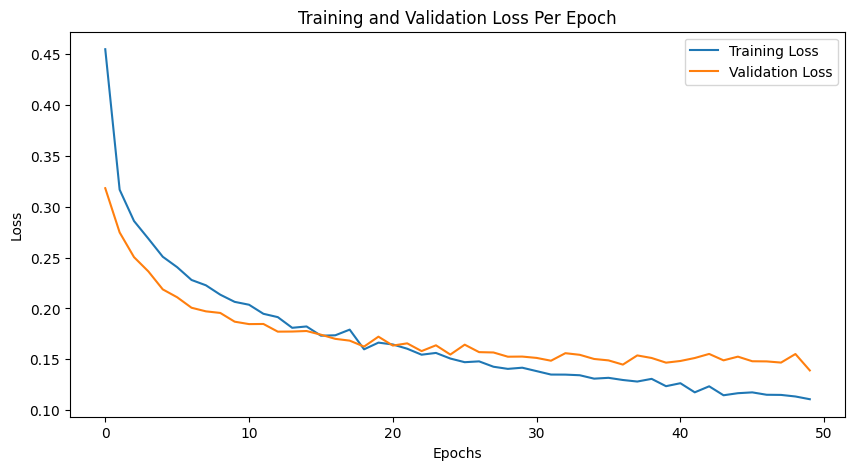

In [50]:
# Define Loss and Optimizer
criterion = nn.BCELoss() # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []

epochs = 50
for epoch in range(epochs):
    model.train()
    batch_train_losses = []
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        batch_train_losses.append(loss.item())

    # Validation phase
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)

    train_losses.append(np.mean(batch_train_losses))
    val_losses.append(val_loss.item())

# Plotting the loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

###Overfitting and Prevention
####Is there overfitting?
#####To detect overfitting, look at the plot above. If the Training Loss continues to decrease while the Validation Loss starts increasing, the model is memorizing the noise in the training data rather than learning general patterns.  
###Techniques used/proposed to prevent overfitting:
####Dropout:
#####Our architecture includes nn.Dropout(0.2), which randomly deactivates 20% of neurons during training to force the model to learn redundant, robust features.  
####Early Stopping:
#####Monitoring validation loss and stopping training once it ceases to improve for several epochs.
####Weight Decay (L2 Regularization):
#####Adding a penalty to large weights in the optimizer (optim.Adam(..., weight_decay=1e-5)) to keep the model simple.

###Comparison with Classical Models

In [51]:
# Evaluate Neural Network
model.eval()
with torch.no_grad():
    nn_preds = (model(X_val_t) > 0.5).float().numpy()
nn_acc = accuracy_score(y_val, nn_preds)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_acc = accuracy_score(y_val, rf.predict(X_val_scaled))

# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)
xgb_acc = accuracy_score(y_val, xgb.predict(X_val_scaled))

print(f"Neural Network Accuracy: {nn_acc:.4f}")
print(f"Random Forest Accuracy:  {rf_acc:.4f}")
print(f"XGBoost Accuracy:        {xgb_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:46:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Neural Network Accuracy: 0.9493
Random Forest Accuracy:  0.9601
XGBoost Accuracy:        0.9626


###Is the use of a Neural Network justified?
#####In many cases for tabular data like this economic dataset, the use of a Neural Network is not fully justified if simple models like Random Forest or XGBoost achieve similar or better accuracy.
####Why?
#####Tabular data lacks the spatial or temporal structure (like images or text) where Deep Learning excels. Models like XGBoost are generally faster to train, easier to interpret, and more robust to smaller datasets without needing extensive hyperparameter tuning.
####When is it justified?
#####A Neural Network is justified if the dataset is extremely large (millions of rows) or if we need to integrate this model into a larger pipeline involving unstructured data (like RAG systems or computer vision).